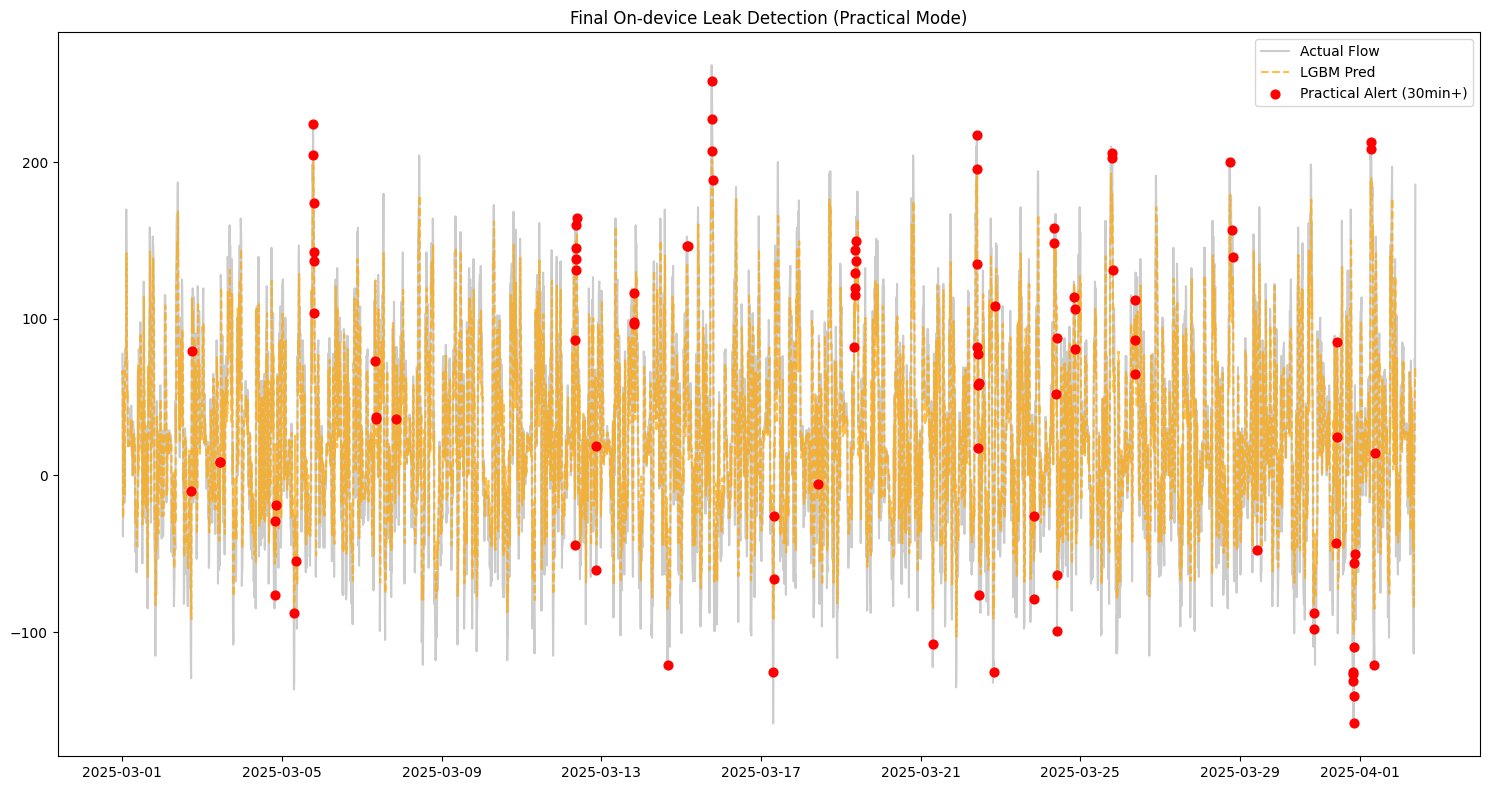

🚩 기존 단순 감지 횟수: 262회
✅ 실무용 지속성 필터 적용 후 알람 횟수: 99회


In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.ensemble import IsolationForest
import joblib
import os
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 경로 설정
input_path = '../data/processed/smart_meter_data.csv'
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

df = pd.read_csv(input_path)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').set_index('Timestamp')

# [특성 공학] 10분 단위 데이터의 과거 1시간(6개) 패턴 학습
def create_features(df):
    df = df.copy()
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['dayofweek'] = df.index.dayofweek
    for i in range(1, 7):
        df[f'flow_lag_{i}'] = df['Flow_Instant'].shift(i)
        df[f'press_lag_{i}'] = df['Pressure'].shift(i)
    return df.dropna()

df_feat = create_features(df)

# 2. 데이터 분할 (학습: 3월 이전 / 테스트: 3월 이후)
train_df = df_feat[df_feat.index < '2025-03-01']
test_df = df_feat[df_feat.index >= '2025-03-01'].copy()

features = ['hour_sin', 'hour_cos', 'dayofweek'] + \
           [f'flow_lag_{i}' for i in range(1, 7)] + \
           [f'press_lag_{i}' for i in range(1, 7)]

# 3. LightGBM 학습 (예측 엔진)
model_lgb = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, verbosity=-1)
model_lgb.fit(train_df[features], train_df['Flow_Instant'])

# 4. 잔차 분석 및 1차 필터 (Z-score 3.0)
test_df['pred'] = model_lgb.predict(test_df[features])
test_df['residual'] = test_df['Flow_Instant'] - test_df['pred']
test_df['res_ewma'] = test_df['residual'].ewm(span=8).mean()

res_mean, res_std = test_df['res_ewma'].mean(), test_df['res_ewma'].std()
test_df['z_score'] = (test_df['res_ewma'] - res_mean) / res_std
test_df['z_flag'] = test_df['z_score'].abs() > 3.0 # 전문가 추천 임계치

# 5. Isolation Forest 학습 (2차 검증)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(train_df[['Flow_Instant', 'Pressure']])
test_df['iso_anomaly'] = iso_forest.predict(test_df[['Flow_Instant', 'Pressure']])

# 6. [핵심] 실무용 지속성 필터 (30분 지속 시 알람)
# 3번 연속(30분)으로 Z-score가 높거나 Isolation Forest가 이상하다고 할 때
test_df['is_anomaly_instant'] = (test_df['z_flag'] == True) | (test_df['iso_anomaly'] == -1)
test_df['final_practical_alert'] = test_df['is_anomaly_instant'].rolling(window=3).sum() == 3

# 7. 모델 저장
joblib.dump(model_lgb, f'{model_dir}/lgbm_leak_predictor.pkl')
joblib.dump(iso_forest, f'{model_dir}/iso_forest_validator.pkl')

# 8. 결과 시각화
plt.figure(figsize=(15, 8))
plt.plot(test_df.index, test_df['Flow_Instant'], label='Actual Flow', alpha=0.4, color='gray')
plt.plot(test_df.index, test_df['pred'], label='LGBM Pred', color='orange', alpha=0.7, ls='--')

# 실무용 확정 알람만 표시
alerts = test_df[test_df['final_practical_alert'] == True]
plt.scatter(alerts.index, alerts['Flow_Instant'], color='red', label='Practical Alert (30min+)', s=40, zorder=5)

plt.title('Final On-device Leak Detection (Practical Mode)')
plt.legend(); plt.tight_layout(); plt.show()

print(f"🚩 기존 단순 감지 횟수: {test_df['is_anomaly_instant'].sum()}회")
print(f"✅ 실무용 지속성 필터 적용 후 알람 횟수: {test_df['final_practical_alert'].sum()}회")
